# Twitter Sentiment Analysis using NLP and Machine Learning

This project classifies tweets/text into Positive, Negative, and Neutral sentiments using Natural Language Processing and Machine Learning techniques.

## 1. Dataset Upload

The Twitter sentiment dataset is uploaded into Google Colab for further processing.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving twitter_training.csv to twitter_training.csv


## 2. Import Libraries and Load Dataset

The dataset is loaded using Pandas. Since the CSV file does not contain column names, custom column names are assigned.

In [2]:
import pandas as pd

df = pd.read_csv("twitter_training.csv", header=None)

df.columns = ["id", "entity", "sentiment", "text"]

df.head()

,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


## 3. Select Required Columns

Only the text and sentiment columns are selected because they are required for sentiment classification.

In [3]:
df = df[["text", "sentiment"]]

df.head()

,text,sentiment
0,im getting on borderlands and i will murder yo...,Positive
1,I am coming to the borders and I will kill you...,Positive
2,im getting on borderlands and i will kill you ...,Positive
3,im coming on borderlands and i will murder you...,Positive
4,im getting on borderlands 2 and i will murder ...,Positive


## 4. Sentiment Distribution

The distribution of sentiment classes is checked to understand the number of samples in each category.

In [4]:
df["sentiment"].value_counts()

,count
sentiment,
Negative,22542
Positive,20832
Neutral,18318
Irrelevant,12990


## 5. Remove Irrelevant Sentiment Class

The Irrelevant class is removed because the project focuses on three sentiment categories: Positive, Negative, and Neutral.

In [5]:
df = df[df["sentiment"] != "Irrelevant"]

df["sentiment"].value_counts()

,count
sentiment,
Negative,22542
Positive,20832
Neutral,18318


## 6. Handle Missing Values

Missing values are removed to avoid errors during text preprocessing and model training.

In [6]:
df = df.dropna()

df.isnull().sum()

,0
text,0
sentiment,0


## 7. Import Machine Learning and NLP Libraries

Required libraries for text preprocessing, vectorization, model training, and evaluation are imported.

In [7]:
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 8. Text Cleaning Function

A custom text cleaning function is created to remove URLs, mentions, hashtags, punctuation, numbers, and extra spaces.

In [8]:
def clean_text(text):
    text = str(text).lower()

    # remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # remove mentions
    text = re.sub(r"@\w+", "", text)

    # remove hashtags symbol only
    text = re.sub(r"#", "", text)

    # remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

## 9. Apply Text Cleaning

The cleaning function is applied to all text values, and a new clean_text column is created.

In [9]:
df["clean_text"] = df["text"].apply(clean_text)

df.head()

,text,sentiment,clean_text
0,im getting on borderlands and i will murder yo...,Positive,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,Positive,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,Positive,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,Positive,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,Positive,im getting on borderlands and i will murder yo...


## 10. Remove Empty Text Rows

Rows with empty cleaned text are removed after preprocessing.

In [10]:
df = df[df["clean_text"] != ""]

df.shape

(60813, 3)

## 11. Define Features and Target Variable

The cleaned text is used as the input feature, and sentiment is used as the target variable.

In [11]:
X = df["clean_text"]
y = df["sentiment"]

## 12. Train-Test Split

The dataset is divided into training and testing sets using an 80:20 split. Stratification is used to maintain class balance.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 13. TF-IDF Vectorization

TF-IDF Vectorization is used to convert text data into numerical features. Unigram and bigram features are used to improve model performance.

In [20]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## 14. Logistic Regression Model Training

A Logistic Regression model is trained on the TF-IDF features for sentiment classification.

In [21]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

## 15. Logistic Regression Model Evaluation

The trained Logistic Regression model is evaluated using accuracy, precision, recall, and F1-score.

In [22]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7948696867549124

Classification Report:

              precision    recall  f1-score   support

    Negative       0.78      0.86      0.82      4451
     Neutral       0.79      0.71      0.75      3596
    Positive       0.81      0.80      0.81      4116

    accuracy                           0.79     12163
   macro avg       0.80      0.79      0.79     12163
weighted avg       0.80      0.79      0.79     12163



## 16. Confusion Matrix

A confusion matrix is used to visualize the correct and incorrect predictions for each sentiment class.

In [16]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3664  408  379]
 [ 671 2371  554]
 [ 548  417 3151]]


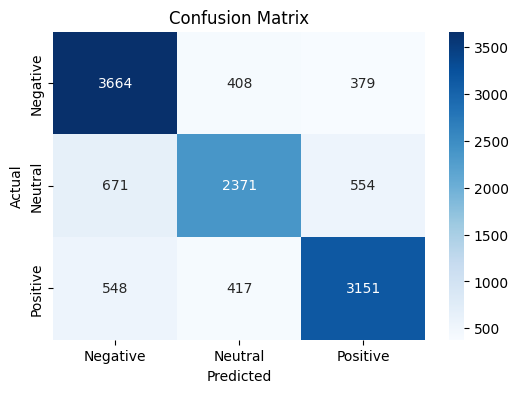

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 17. Custom Sentiment Prediction Function

A function is created to predict the sentiment of new user-entered text.

In [23]:
def predict_sentiment(text):
    cleaned_text = clean_text(text)
    vectorized_text = vectorizer.transform([cleaned_text])
    prediction = model.predict(vectorized_text)
    return prediction[0]

## 18. Custom Sentence Testing

The model is tested on custom sentences to check real-time sentiment prediction performance.

In [25]:
test_sentences = [
    "I absolutely love this product, it works perfectly",
    "This is the worst service I have ever used",
    "The update is available today",
    "I am very happy with the new features",
    "The experience was terrible and disappointing",
    "The product is okay and works as expected",
    "I hate this app because it keeps crashing",
    "The movie was average, not good or bad"
]

for sentence in test_sentences:
    print(sentence, "->", predict_sentiment(sentence))

I absolutely love this product, it works perfectly -> Positive
This is the worst service I have ever used -> Negative
The update is available today -> Negative
I am very happy with the new features -> Positive
The experience was terrible and disappointing -> Negative
The product is okay and works as expected -> Positive
I hate this app because it keeps crashing -> Negative
The movie was average, not good or bad -> Neutral


## 19. Naive Bayes Model Training and Evaluation

A Naive Bayes model is also trained and evaluated to compare its performance with Logistic Regression.

In [26]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)
print("\nNaive Bayes Classification Report:\n")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.7407711913179315

Naive Bayes Classification Report:

              precision    recall  f1-score   support

    Negative       0.72      0.84      0.78      4451
     Neutral       0.78      0.58      0.67      3596
    Positive       0.74      0.77      0.75      4116

    accuracy                           0.74     12163
   macro avg       0.75      0.73      0.73     12163
weighted avg       0.75      0.74      0.74     12163



## 20. Model Comparison

The accuracies of Logistic Regression and Naive Bayes are compared to select the best-performing model.

In [27]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [accuracy, nb_accuracy]
})

results

,Model,Accuracy
0,Logistic Regression,0.794870
1,Naive Bayes,0.740771


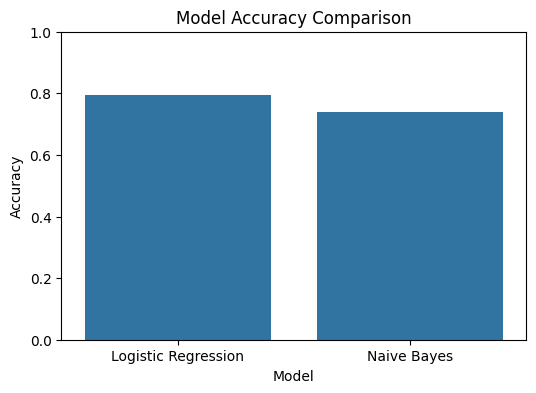

In [28]:
plt.figure(figsize=(6,4))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

## 21. Save Final Model and Vectorizer

The best-performing Logistic Regression model and TF-IDF vectorizer are saved using Pickle for deployment.

In [29]:
import pickle

with open("sentiment_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("Final model and vectorizer saved successfully!")

Final model and vectorizer saved successfully!


## 22. Download Saved Model Files

The saved model and vectorizer files are downloaded for use in the Streamlit application.

In [30]:
from google.colab import files

files.download("sentiment_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 23. Conclusion

In this project, a Twitter sentiment analysis system was developed using NLP and machine learning. The dataset was cleaned and preprocessed, and TF-IDF vectorization with unigram and bigram features was applied. Two machine learning models, Logistic Regression and Naive Bayes, were trained and compared.

Logistic Regression achieved the highest accuracy of 79.48%, while Naive Bayes achieved 74.07%. Therefore, Logistic Regression was selected as the final model. The model performs well on clear positive and negative text, while neutral or ambiguous text can be more challenging to classify.